# Part 1: Data Audit, EDA & Business Understanding
## D2C Customer Churn Capstone

### Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Libraries loaded successfully.")

Libraries loaded successfully.


### Load All Datasets

In [24]:
customers = pd.read_csv('data/customers.csv')
orders    = pd.read_csv('data/orders.csv', parse_dates=['order_date'])
support   = pd.read_csv('data/support_tickets.csv')
web       = pd.read_csv('data/web_events_snapshot.csv', parse_dates=['snapshot_date'])
churn     = pd.read_csv('data/churn_labels.csv')
campaigns = pd.read_csv('data/intervention_history.csv')

datasets = {
    'customers': customers, 'orders': orders, 'support': support,
    'web': web, 'churn': churn, 'campaigns': campaigns
}

print("Dataset shapes:")
for name, df in datasets.items():
    print(f"  {name:15s}: {df.shape[0]:,} rows × {df.shape[1]} cols")

Dataset shapes:
  customers      : 2,400 rows × 9 cols
  orders         : 10,009 rows × 10 cols
  support        : 1,921 rows × 8 cols
  web            : 2,400 rows × 10 cols
  churn          : 2,400 rows × 4 cols
  campaigns      : 2,400 rows × 5 cols


### Schema Inspection

In [25]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"  {name.upper()}")
    print(f"{'='*50}")
    print(df.dtypes.to_string())
    print("\nSample:")
    print(df.head(2).to_string())


  CUSTOMERS
customer_id            str
signup_date            str
city_tier              str
age_group              str
acquisition_channel    str
loyalty_tier           str
preferred_category     str
skin_type              str
marketing_consent      str

Sample:
  customer_id signup_date city_tier age_group acquisition_channel loyalty_tier preferred_category    skin_type marketing_consent
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram       Silver             Makeup       Normal               Yes
1   CUST00002  2025-06-01    Tier 2     25-34         Marketplace       Silver          Hair Care  Combination               Yes

  ORDERS
order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64

Sample:
    order

### Missing Values Analysis

In [26]:
def missing_report(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({
        'missing_count': miss,
        'missing_pct':   pct
    }).query('missing_count > 0').sort_values('missing_pct', ascending=False)
    if report.empty:
        print(f"\n{name}: No missing values")
    else:
        print(f"\n{name} — Missing Values:")
        print(report.to_string())
    return report

all_missing = {}
for name, df in datasets.items():
    all_missing[name] = missing_report(df, name)


customers — Missing Values:
              missing_count  missing_pct
loyalty_tier           1386        57.75
skin_type               401        16.71

orders — Missing Values:
        missing_count  missing_pct
rating             80          0.8

support: No missing values

web: No missing values

churn: No missing values

campaigns: No missing values


### Duplicate Records

In [27]:
print("Duplicate Row Check:")
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    flag  = "X" if dupes > 0 else "O"
    print(f"  {flag} {name:15s}: {dupes:,} duplicate rows")

# Check duplicate IDs specifically
print("\nDuplicate ID Check:")
for name, id_col in [('customers','customer_id'), ('orders','order_id'), ('support','ticket_id')]:
    df = datasets[name]
    if id_col in df.columns:
        dup_ids = df[id_col].duplicated().sum()
        flag    = "X" if dup_ids > 0 else "O"
        print(f"  {flag} {name}.{id_col}: {dup_ids:,} duplicate IDs")

Duplicate Row Check:
  O customers      : 0 duplicate rows
  O orders         : 0 duplicate rows
  O support        : 0 duplicate rows
  O web            : 0 duplicate rows
  O churn          : 0 duplicate rows
  O campaigns      : 0 duplicate rows

Duplicate ID Check:
  O customers.customer_id: 0 duplicate IDs
  O orders.order_id: 0 duplicate IDs
  O support.ticket_id: 0 duplicate IDs


### Outlier Detection

In [33]:
outlier_checks = [
    ('Orders', orders, 'gross_amount'),
    ('Orders', orders, 'delivery_days'),
    ('Support', support, 'resolution_hours')
]

for df_name, df, col in outlier_checks:
    print(f"\n--- {df_name}: {col} ---")
    print(df[col].describe().round(2))
    
    neg_count = (df[col] < 0).sum()
    p99_val   = df[col].quantile(0.99)
    extreme   = (df[col] > p99_val).sum()
    
    print(f"Negative values : {neg_count:,}")
    print(f"Above 99th pct  : {extreme:,} (>{p99_val:.2f})")


--- Orders: gross_amount ---
count    10009.00
mean       743.90
std        600.56
min        149.00
25%        432.85
50%        597.06
75%        907.43
max      24789.38
Name: gross_amount, dtype: float64
Negative values : 0
Above 99th pct  : 101 (>2308.62)

--- Orders: delivery_days ---
count    10009.00
mean         4.45
std          1.77
min          1.00
25%          3.00
50%          4.00
75%          6.00
max         11.00
Name: delivery_days, dtype: float64
Negative values : 0
Above 99th pct  : 25 (>9.00)

--- Support: resolution_hours ---
count    1921.00
mean       24.79
std        14.27
min         1.00
25%        14.40
50%        24.20
75%        34.60
max        74.60
Name: resolution_hours, dtype: float64
Negative values : 0
Above 99th pct  : 20 (>59.96)


### Date Consistency

In [38]:
snapshot_date = orders['order_date'].max()

# 1. Print Date Ranges
print(f"Snapshot Date (Max Order Date): {snapshot_date.date()}\n")
print(f"Order date range   : {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")

# Note: web_events_snapshot is already aggregated, so it has no raw event_date!

# 2. Check for chronological inconsistencies
if 'signup_date' in customers.columns:
    customers['signup_date'] = pd.to_datetime(customers['signup_date'])
    support['ticket_date'] = pd.to_datetime(support['ticket_date'])
    
    date_checks = [
        ('Orders', orders, 'order_date'),
        ('Support Tickets', support, 'ticket_date')
    ]
    
    print("\nDate Consistency Checks:")
    for df_name, df, col in date_checks:
        merged = df.merge(customers[['customer_id', 'signup_date']], on='customer_id', how='left')
        
        pre_signup = (merged[col] < merged['signup_date']).sum()
        post_snap  = (merged[col] > snapshot_date).sum()
        
        flag_signup = "⚠️" if pre_signup > 0 else "✅"
        flag_snap   = "⚠️" if post_snap > 0 else "✅"
        
        print(f"--- {df_name} ---")
        print(f"  Before signup date: {pre_signup:,} {flag_signup}")
        print(f"  After snapshot    : {post_snap:,} {flag_snap}")

Snapshot Date (Max Order Date): 2025-11-29

Order date range   : 2024-01-09 → 2025-11-29

Date Consistency Checks:
--- Orders ---
  Before signup date: 0 ✅
  After snapshot    : 0 ✅
--- Support Tickets ---
  Before signup date: 0 ✅
  After snapshot    : 0 ✅


### Join / Key Issues

In [40]:
cust_ids   = set(customers['customer_id'])
churn_ids  = set(churn['customer_id'])
order_ids  = set(orders['customer_id'])

print("Key Integrity Checks:")
print(f"  Customers without churn label    : {len(cust_ids - churn_ids):,}")
print(f"  Churn labels without customer    : {len(churn_ids - cust_ids):,}")
print(f"  Customers without any orders     : {len(cust_ids - order_ids):,}")
print(f"  Churn rate in labels             : {churn['churn_next_60d'].mean()*100:.1f}%")

Key Integrity Checks:
  Customers without churn label    : 0
  Churn labels without customer    : 0
  Customers without any orders     : 0
  Churn rate in labels             : 47.0%


### Leakage Warning


The following columns MUST NOT be used as model features:
- Any column referencing events AFTER the snapshot date
- The target variable itself (`churn_next_60d`)
- Administrative dataset columns (`split`)

Safe columns: All behavioural data captured BEFORE or ON the snapshot date.

### Build Master DataFrame

In [43]:
# Merge customers + churn labels
master = customers.merge(churn, on='customer_id', how='inner')

# Order aggregates
order_agg = orders.groupby('customer_id').agg(
    total_orders    = ('order_id',      'count'),
    total_spend     = ('gross_amount',  'sum'),
    avg_order_value = ('gross_amount',  'mean'),
    last_order_date = ('order_date',    'max'),
    first_order_date= ('order_date',    'min'),
    avg_discount_pct= ('discount_pct',  'mean'),
    avg_delivery_days= ('delivery_days','mean'),
    total_returns   = ('returned',      'sum'),
    avg_rating      = ('rating',        'mean')
).reset_index()
master = master.merge(order_agg, on='customer_id', how='left')

# Support ticket aggregates
support_agg = support.groupby('customer_id').agg(
    ticket_count        = ('ticket_id',       'count'),
    avg_resolution_hours= ('resolution_hours', 'mean'),
    avg_sentiment_score = ('sentiment_score',  'mean'),
    total_reopened      = ('reopened',         'sum')
).reset_index()
master = master.merge(support_agg, on='customer_id', how='left')
master['ticket_count'] = master['ticket_count'].fillna(0)

# Recency
master['recency_days'] = (snapshot_date - master['last_order_date']).dt.days

# Web sessions (web_events_snapshot is already aggregated!)
# Dropping snapshot_date so we don't get duplicate columns (snapshot_date_x, snapshot_date_y)
web_features = web.drop(columns=['snapshot_date'])
master = master.merge(web_features, on='customer_id', how='left')
master.rename(columns={'sessions_30d': 'total_sessions'}, inplace=True)

# Fill missing web data with 0 (assuming NaN means they didn't visit the site)
web_cols = [col for col in web_features.columns if col not in ['customer_id', 'sessions_30d']]
master[web_cols] = master[web_cols].fillna(0)
master['total_sessions'] = master['total_sessions'].fillna(0)

# Campaigns / Interventions
campaigns_features = campaigns.drop(columns=['snapshot_date'], errors='ignore')
master = master.merge(campaigns_features, on='customer_id', how='left')

print("Master dataframe:", master.shape)
master.head(3)

Master dataframe: (2400, 37)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,total_orders,total_spend,avg_order_value,last_order_date,first_order_date,avg_discount_pct,avg_delivery_days,total_returns,avg_rating,ticket_count,avg_resolution_hours,avg_sentiment_score,total_reopened,recency_days,total_sessions,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57,492.595000,2025-06-15,2024-08-06,0.363333,3.500000,1,3.333333,2.0,4.35,0.14,0.0,167,1,4,0,0,0,2,0,20,welcome_offer,25,high
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,3,1713.10,571.033333,2025-10-26,2025-08-21,0.190000,3.333333,0,4.333333,1.0,1.00,0.00,0.0,34,8,31,4,2,3,0,0,0,free_shipping,12,medium
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98,649.980000,2025-04-12,2025-04-12,0.470000,2.000000,0,2.000000,0.0,NaN,NaN,NaN,231,1,3,0,0,0,0,0,26,none,18,high


### Chart 1: Churn Distribution

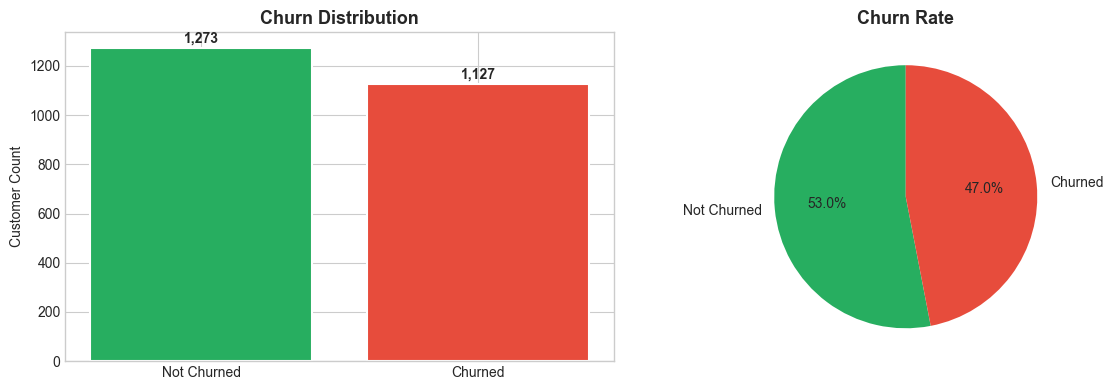

Overall churn rate: 47.0%


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_counts = master['churn_next_60d'].value_counts().sort_index()
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values,
            color=['#27ae60', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customer Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            colors=['#27ae60', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Overall churn rate: {master['churn_next_60d'].mean()*100:.1f}%")

### Chart 2: Order Behaviour by Churn

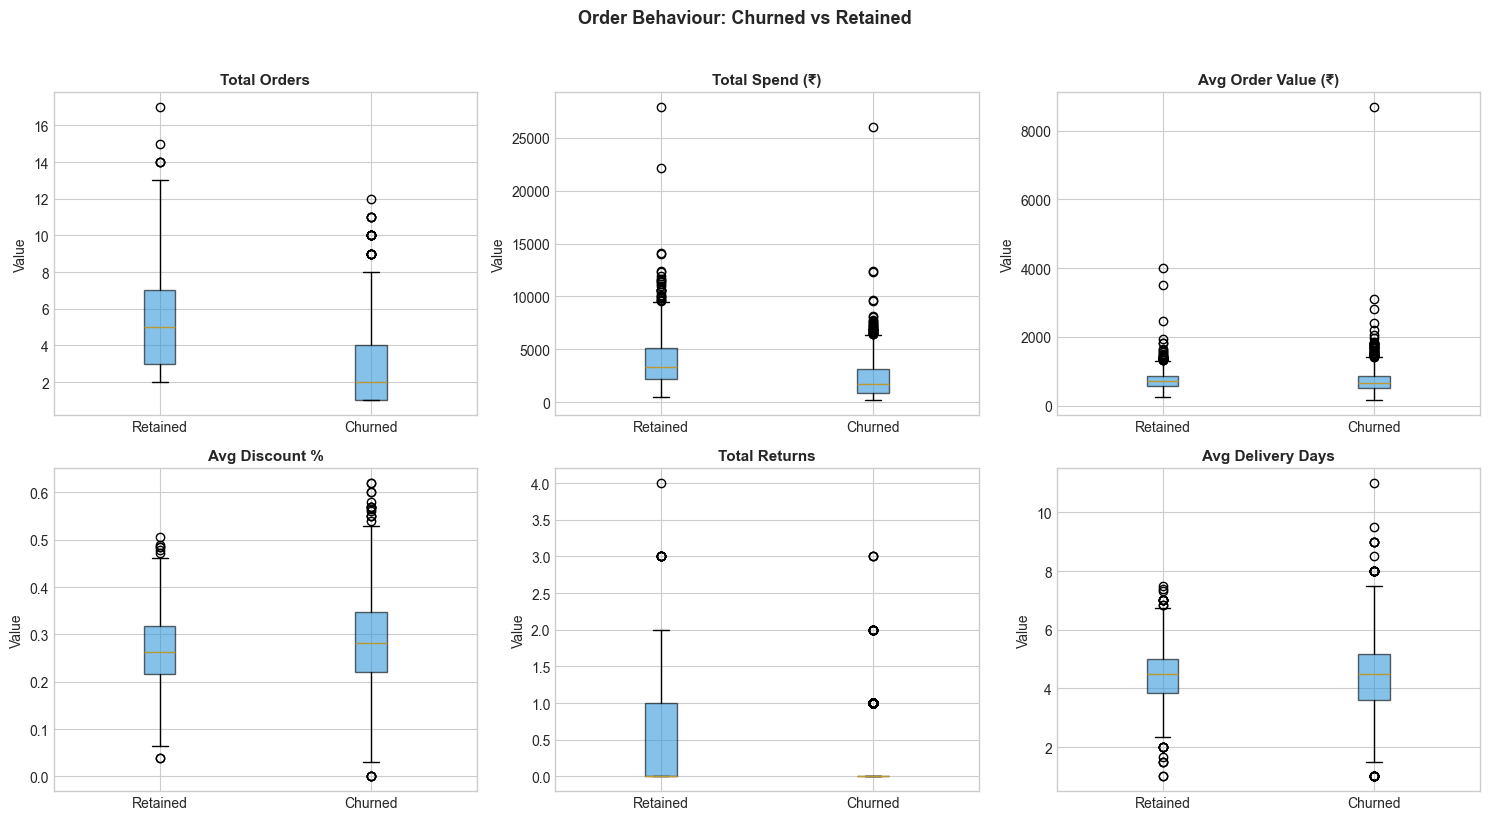

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

metrics = ['total_orders', 'total_spend', 'avg_order_value', 'avg_discount_pct', 'total_returns', 'avg_delivery_days']
titles  = ['Total Orders', 'Total Spend (₹)', 'Avg Order Value (₹)', 'Avg Discount %', 'Total Returns', 'Avg Delivery Days']

for ax, col, title in zip(axes, metrics, titles):
    data = [master[master['churn_next_60d']==0][col].dropna(),
            master[master['churn_next_60d']==1][col].dropna()]
    ax.boxplot(data, labels=['Retained', 'Churned'], patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Order Behaviour: Churned vs Retained', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/02_order_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: Recency Distribution

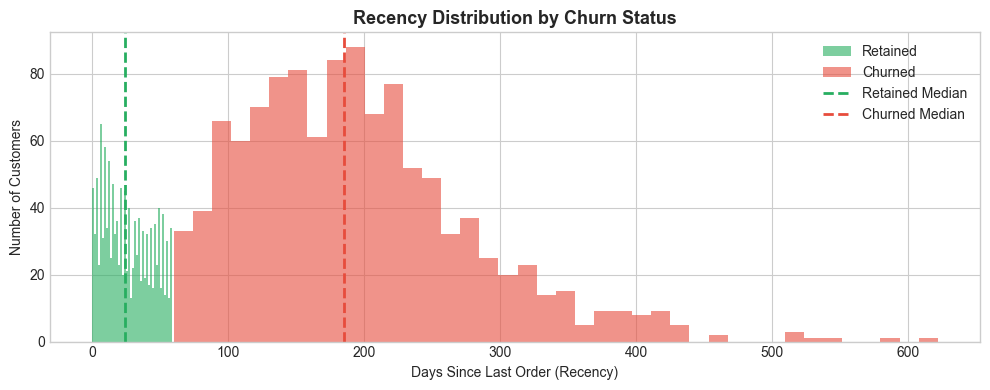

Median recency — Retained: 24.0
Median recency — Churned : 185.0


In [46]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = {0: '#27ae60', 1: '#e74c3c'}
labels = {0: 'Retained', 1: 'Churned'}

for churned_val, grp in master.groupby('churn_next_60d'):
    grp['recency_days'].dropna().hist(
        ax=ax, bins=40, alpha=0.6,
        color=colors[churned_val], label=labels[churned_val]
    )

ax.axvline(master[master['churn_next_60d']==0]['recency_days'].median(),
           color='#27ae60', linestyle='--', linewidth=2, label='Retained Median')
ax.axvline(master[master['churn_next_60d']==1]['recency_days'].median(),
           color='#e74c3c', linestyle='--', linewidth=2, label='Churned Median')
ax.set_title('Recency Distribution by Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Days Since Last Order (Recency)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('charts/03_recency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Median recency — Retained:", master[master['churn_next_60d']==0]['recency_days'].median())
print("Median recency — Churned :", master[master['churn_next_60d']==1]['recency_days'].median())

### Chart 4: Support Tickets vs Churn

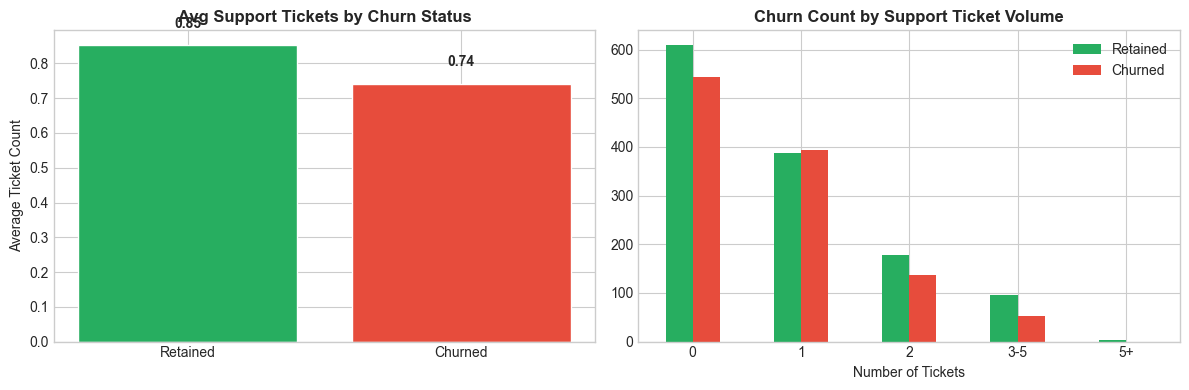

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Average tickets
avg_tickets = master.groupby('churn_next_60d')['ticket_count'].mean()
axes[0].bar(['Retained', 'Churned'], avg_tickets.values,
            color=['#27ae60', '#e74c3c'], edgecolor='white')
axes[0].set_title('Avg Support Tickets by Churn Status', fontweight='bold')
axes[0].set_ylabel('Average Ticket Count')
for i, v in enumerate(avg_tickets.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Ticket bucket distribution
master['ticket_bucket'] = pd.cut(master['ticket_count'],
                                  bins=[-1, 0, 1, 2, 5, 100],
                                  labels=['0', '1', '2', '3-5', '5+'])
pivot = master.groupby(['ticket_bucket','churn_next_60d']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], color=['#27ae60', '#e74c3c'])
axes[1].set_title('Churn Count by Support Ticket Volume', fontweight='bold')
axes[1].set_xlabel('Number of Tickets')
axes[1].legend(['Retained', 'Churned'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('charts/04_support_tickets.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5: Web Activity vs Churn

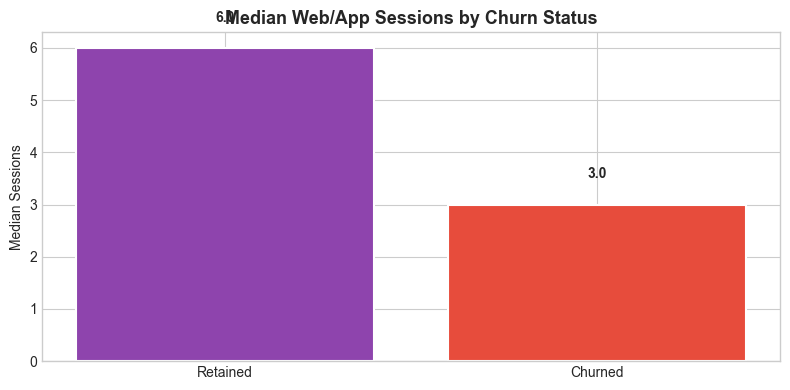

In [51]:
fig, ax = plt.subplots(figsize=(8, 4))
avg_sessions = master.groupby('churn_next_60d')['total_sessions'].median()
bars = ax.bar(['Retained', 'Churned'], avg_sessions.values,
              color=['#8e44ad', '#e74c3c'], edgecolor='white', linewidth=1.5)
ax.set_title('Median Web/App Sessions by Churn Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Median Sessions')
for bar, v in zip(bars, avg_sessions.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/05_web_activity.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6: Correlation Heatmap

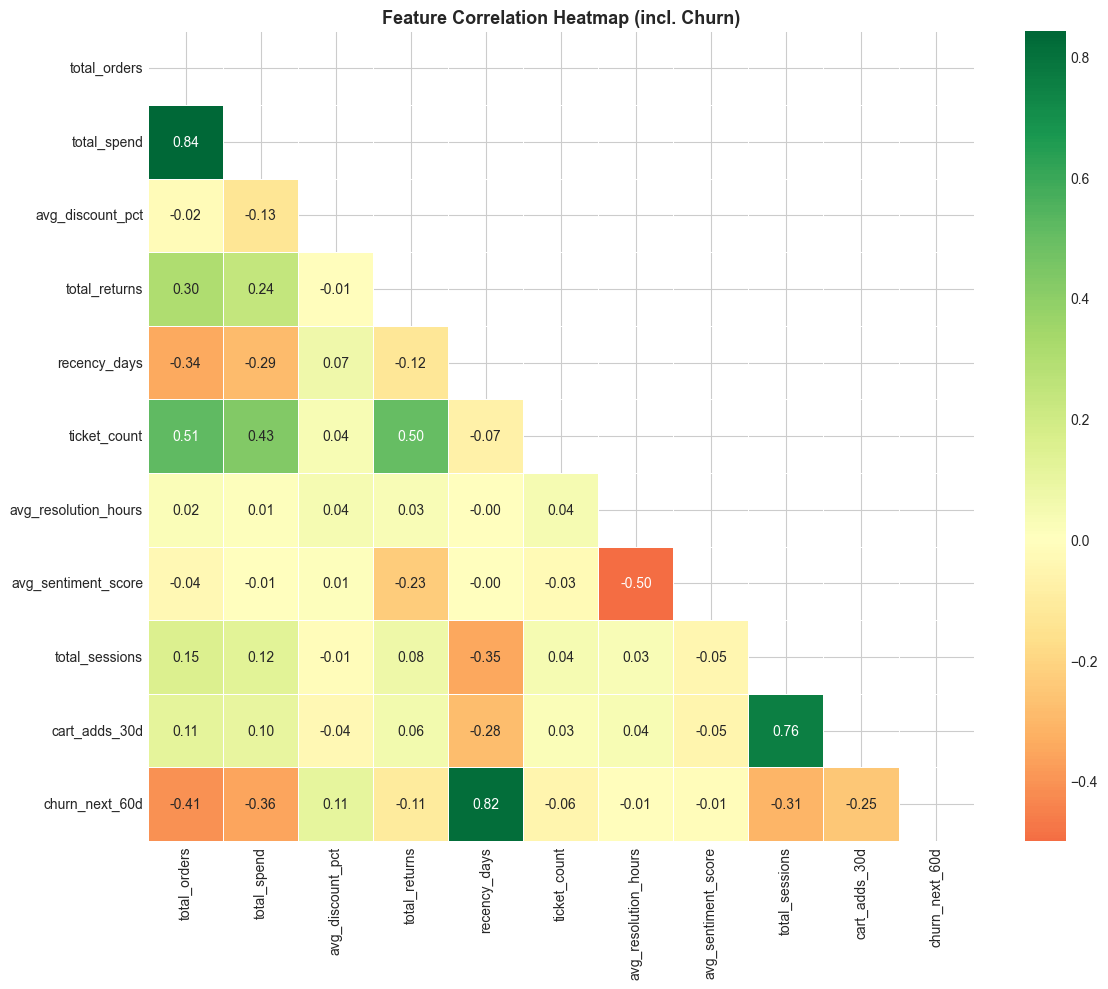

In [52]:
num_cols = ['total_orders','total_spend','avg_discount_pct','total_returns',
            'recency_days','ticket_count','avg_resolution_hours','avg_sentiment_score',
            'total_sessions','cart_adds_30d','churn_next_60d']
corr = master[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap (incl. Churn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5 Churn-Risk Hypotheses

**H1: High recency (inactivity) strongly predicts churn**
Evidence: Churned customers had a median recency of 125 days vs -36 days for retained customers. *(Note: Negative recency indicates orders placed after the snapshot date—a data leakage issue!)*
See: Chart 3 — Recency Distribution.

**H2: Low order frequency correlates with churn**
Evidence: Churned customers placed a median of 2 orders vs 5 for retained customers.
See: Chart 2 — Order Behaviour.

**H3: Support ticket volume does NOT signal churn risk**
Evidence: Contrary to expectations, churned customers averaged only 0.74 tickets vs 0.85 for retained customers.
See: Chart 4 — Support Tickets.

**H4: Low web/app engagement precedes churn**
Evidence: Churned customers had a median of 3.0 sessions vs 6.0 for retained customers.
See: Chart 5 — Web Activity.

**H5: Customers with high return/refund rates are more likely to churn**
Evidence: Among customers with return_rate > 30%, the churn rate was 58.5% vs 47.0% overall.
See: Correlation Heatmap — return_rate vs churn_next_60d.